# Livrable 2 — Heuristique NNH + 2-opt pour le VRPTW
**Recherche Opérationnelle** · Phase 2 · Méthode : Nearest Neighbor Heuristic + amélioration locale 2-opt

---

| | |
|---|---|
| **Algorithme** | NNH (construction) + 2-opt (amélioration locale) |
| **Instances** | 30 instances × 5 tailles ($n \in \{10,20,30,40,50\}$) |
| **Validité** | 100 % de solutions faisables |
| **Langage** | Python 3 · NumPy · pandas · matplotlib |


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats

# ═══════════════════════════════════════════════════════════════════════
#  DESIGN SYSTEM — copier ce bloc pour harmoniser les graphiques d'équipe
#  Seul METHODE_CONFIG change d'un binôme à l'autre
# ═══════════════════════════════════════════════════════════════════════

STYLE_CONFIG = {
    # Palette
    'couleur_primaire' : '#2176AE',   # bleu principal
    'couleur_alt'      : '#FF6B35',   # orange accent
    'couleur_ic'       : '#A8D5F5',   # fill intervalles de confiance
    'couleur_grid'     : '#E8E8E8',
    'couleur_fond'     : '#FAFAFA',
    # Typographie
    'font_titre'       : {'fontsize': 14, 'fontweight': 'bold', 'color': '#1a1a1a'},
    'font_sous_titre'  : {'fontsize': 11, 'fontstyle': 'italic', 'color': '#555555'},
    'font_axe'         : {'fontsize': 10},
    'font_legende'     : {'size': 9},
    'font_annot'       : {'fontsize': 7.5, 'family': 'monospace', 'color': '#1a1a1a'},
    # Figures
    'figsize_simple'   : (8, 5),
    'figsize_double'   : (12, 5),
    'figsize_quad'     : (13, 10),
    # Traits
    'marker'           : 'o',
    'linestyle'        : '-',
    'linewidth'        : 2.0,
    'markersize'       : 6,
    # Divers
    'dpi'              : 130,
    'grid_alpha'       : 0.5,
    'box_alpha'        : 0.85,
}

# ── Identification de la méthode (seul bloc à modifier par binôme) ──────
METHODE_CONFIG = {
    'nom'      : 'NNH + 2-opt',
    'csv_path' : os.path.join('resultats', 'resultats_nnh.csv'),
}

# ── Dossier figures ──────────────────────────────────────────────────────
FIG_DIR = os.path.join('resultats', 'livrable_figures')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Méthode : {METHODE_CONFIG['nom']}")
print(f"Figures → {FIG_DIR}/")


Méthode : NNH + 2-opt
Figures → resultats\livrable_figures/


---
## 1. Le Problème — VRPTW

### 1.1 Définition formelle

Le **Vehicle Routing Problem with Time Windows (VRPTW)** est un problème d'optimisation
combinatoire classé **NP-difficile**. Il généralise le problème du voyageur de commerce
en ajoutant une flotte de véhicules et des contraintes temporelles.

**Données d'entrée :**
- Un dépôt (nœud $0$) et $n$ clients numérotés $1 \ldots n$
- Une flotte de $K$ véhicules identiques de capacité $Q$
- Pour chaque client $i$ : demande $d_i$, fenêtre $[a_i, b_i]$, temps de service $s_i$
- Matrice de distances $c_{ij}$ et de durées de trajet $t_{ij}$

**Objectif :** Minimiser le coût total de déplacement

$$\min \sum_{k \in \mathcal{K}} \sum_{(i,j) \in \mathcal{A}} c_{ij} \cdot x_{ijk}$$

**Contraintes :**

| Code | Énoncé |
|------|--------|
| **C1** | Chaque client est visité exactement une fois |
| **C2** | Chaque route commence et termine au dépôt |
| **C3** | $\sum_{i \in \text{route}_k} d_i \leq Q$ (capacité du véhicule) |
| **C4** | $a_i \leq \tau_i \leq b_i$ (arrivée dans la fenêtre temporelle) |
| **C5** | $\tau_{\text{retour}} \leq H$ (retour avant la fin de journée) |

### 1.2 Paramètres des instances

| Paramètre | Valeur |
|-----------|--------|
| Tailles | $n \in \{10, 20, 30, 40, 50\}$ |
| Flotte | $K = \max(3,\, \lceil n/10 \rceil)$ véhicules |
| Capacité | $Q = 1.4 \times \bar{d} \times K$ |
| Fenêtres TW | largeur $\sim \mathcal{U}(60, 90)$ min, ancrées sur $t^{\min}_{0 \to i}$ |
| Horizon | $H = 480$ min (8 h) |
| Seeds | $0 \to 29$ · 30 instances par taille |


---
## 2. Vulgarisation — L'analogie du livreur

Imaginez que vous êtes **responsable logistique** pour un entrepôt Amazon un matin de
Black Friday. Vous avez **5 camions** et **50 clients** à livrer avant la fin de journée.
Chaque client a passé commande avec un créneau horaire précis : *« livrez-moi entre
10h et 11h »*. Si vous arrivez en dehors du créneau, la livraison est refusée.

**Le défi :** qui livre qui, dans quel ordre, pour parcourir le moins de kilomètres ?

### Étape 1 — NNH : le livreur qui suit son instinct

> Le premier livreur sort de l'entrepôt et va **toujours vers le client le plus proche**
> accessible (créneau compatible, camion pas plein). Quand il ne peut plus prendre
> personne, il rentre. Le deuxième livreur prend le relais, et ainsi de suite.

C'est rapide, intuitif, mais pas toujours optimal : parfois on passe à côté d'un
meilleur chemin global parce qu'on ne regarde que devant soi.

### Étape 2 — 2-opt : le GPS qui recalcule

> Une fois que chaque livreur a sa tournée, on essaie d'améliorer chaque route
> individuellement. On teste si **inverser un segment** de la route raccourcirait
> la distance sans violer les créneaux.

```
Avant : Dépôt → A → B → C → D → Dépôt
Test  : inverser [B, C] → Dépôt → A → C → B → D → Dépôt
Si la nouvelle route est plus courte ET valide → on l'accepte ✓
```

C'est exactement ce que fait un GPS quand il recalcule pour éliminer les croisements
inutiles dans votre itinéraire.

### Pourquoi pas une recherche exhaustive ?

Pour $n = 50$ clients, le nombre de routes possibles est de l'ordre de $50! \approx 3 \times 10^{64}$.
Même un ordinateur testant $10^{12}$ solutions par seconde mettrait $10^{52}$ années.
L'heuristique donne une **bonne solution en quelques millisecondes**.


---
## 3. Méthodologie Technique

### 3.1 Phase 1 — Nearest Neighbor Heuristic (NNH)

L'algorithme NNH est une **heuristique constructive gloutonne** :
à chaque étape, on prend la décision localement optimale sans revenir en arrière.

**Pseudo-code :**
```
non_livrés ← {1 … n}
Tant que non_livrés ≠ ∅ :
    Ouvrir un nouveau véhicule k (pos=dépôt, t=0, charge=0)
    Tant que ∃ client accessible :
        i* ← argmin_{i ∈ non_livrés} dist(pos, i)
               sous contraintes C3, C4, C5
        Ajouter i* à la route k
        Mettre à jour pos, t, charge
    Fermer la route k (retour au dépôt)
```

**Complexité :** $O(n^2)$ par véhicule → $O(n^3)$ pire cas, $O(n^2)$ en pratique.

**Limites :** NNH ne fait pas de retours en arrière. Si un client très éloigné est
attribué à un véhicule par manque d'alternative locale, la solution globale se dégrade.
C'est pourquoi le 2-opt est indispensable.

### 3.2 Phase 2 — Amélioration 2-opt intra-route

Pour une route $r = [r_0, r_1, \ldots, r_m]$, une inversion du segment $[i, j]$ donne :

$$r' = [r_0, \ldots, r_{i-1},\ r_j, r_{j-1}, \ldots, r_i,\ r_{j+1}, \ldots, r_m]$$

Le **gain** de l'inversion est :

$$\Delta(i,j) = \underbrace{c(r_{i-1}, r_i) + c(r_j, r_{j+1})}_{\text{anciens arcs}}
              - \underbrace{c(r_{i-1}, r_j) + c(r_i, r_{j+1})}_{\text{nouveaux arcs}}$$

On accepte si $\Delta > 0$ **ET** la route inversée respecte C3, C4, C5.
L'algorithme s'arrête quand aucune paire $(i,j)$ n'améliore la solution
→ **optimum local 2-opt**.

**Complexité :** $O(m^2)$ paires par itération, $O(m^4)$ pire cas,
$O(m^2)$–$O(m^3)$ en pratique sur instances TW-contraintes.

### 3.3 Pourquoi les fenêtres temporelles limitent le 2-opt ?

Dans un TSP classique, toute inversion qui raccourcit la distance est valide.
Avec les fenêtres temporelles, **inverser un segment peut changer l'ordre de visite**
et ainsi violer les créneaux de certains clients.
Le 2-opt VRPTW est donc plus conservateur : certaines améliorations géométriques
sont rejetées pour préserver la faisabilité → gain moyen plus faible qu'en TSP pur.


---
## 4. Analyse du Code

Les trois fonctions clés du fichier `heuristique.py` sont détaillées ci-dessous.


### 4.1 `est_valide(route, instance)` — Vérificateur de contraintes

Cette fonction simule le trajet complet d'un véhicule et vérifie les trois contraintes
actives :

| Contrainte | Test | Cause de rejet la plus fréquente |
|-----------|------|-----------------------------------|
| **C3** capacité | `sum(demands) ≤ Q` | Rare (capacité calibrée à 1.4×) |
| **C4** fenêtre TW | `t_arrivée ≤ b_i` | Créneau fermé si route trop longue |
| **C5** horizon | `t_retour ≤ H` | Route fermée trop tard (~97% des rejets) |

**Subtilité :** si le véhicule arrive *avant* l'ouverture du créneau ($t < a_i$),
il attend ($t \leftarrow \max(t, a_i)$) — cette attente consomme du temps H.


In [2]:
# ── Extrait de est_valide() ─────────────────────────────────────────────────
def est_valide(route, instance):
    if not route:
        return True

    durees, tw, service  = instance['durees'], instance['time_windows'], instance['service_times']
    demands, capacity    = instance['demands'], instance['capacity']
    horizon              = instance['horizon']

    # C3 — capacité
    if sum(demands[c] for c in route) > capacity + 1e-6:
        return False

    t, pos = 0.0, 0
    for client in route:
        t   = t + durees[pos, client]
        t   = max(t, tw[client, 0])         # attente si arrivée trop tôt
        if t > tw[client, 1] + 1e-6:        # C4 — fenêtre temporelle
            return False
        t  += service[client]
        pos = client

    if t + durees[pos, 0] > horizon + 1e-6:  # C5 — horizon
        return False
    return True

print("Fonction est_valide() définie (démonstration — non exécutée sur instance réelle)")


Fonction est_valide() définie (démonstration — non exécutée sur instance réelle)


### 4.2 `construire_solution_nnh(instance)` — Constructeur NNH

Voici les parties les plus importantes de la boucle NNH. Notez la **pré-détection
des clients fondamentalement infaisables** avant même de lancer les véhicules.


In [3]:
# ── Extrait de construire_solution_nnh() — boucle principale ───────────────
def _nnh_loop_demo(instance):
    n, dist, durees = instance['n'], instance['dist'], instance['durees']
    tw, service     = instance['time_windows'], instance['service_times']
    demands, capacity, horizon = instance['demands'], instance['capacity'], instance['horizon']

    routes             = []
    clients_non_livres = set(range(1, n + 1))

    while clients_non_livres:
        route = []
        pos, t, capacite_restante = 0, 0.0, capacity

        while True:
            meilleur_client, meilleure_dist = None, float('inf')

            for client in clients_non_livres:
                if demands[client] > capacite_restante + 1e-6:      # C3
                    continue
                t_arr = max(t + durees[pos, client], tw[client, 0])
                if t_arr > tw[client, 1] + 1e-6:                     # C4
                    continue
                if t_arr + service[client] + durees[client, 0] > horizon + 1e-6:  # C5
                    continue
                d = dist[pos, client]
                if d < meilleure_dist:
                    meilleure_dist, meilleur_client = d, client

            if meilleur_client is None:
                break   # ← véhicule saturé ou aucun client accessible

            # Ajout du meilleur client à la route
            route.append(meilleur_client)
            clients_non_livres.discard(meilleur_client)
            t_arr              = max(t + durees[pos, meilleur_client], tw[meilleur_client, 0])
            t                  = t_arr + service[meilleur_client]
            capacite_restante -= demands[meilleur_client]
            pos                = meilleur_client

        if route:
            routes.append(route)

    return routes

print("Fonction _nnh_loop_demo() définie (démonstration)")


Fonction _nnh_loop_demo() définie (démonstration)


### 4.3 `ameliorer_2opt(routes, instance)` — Optimiseur local

La double boucle $(i, j)$ est le cœur du 2-opt. La validation VRPTW avant acceptation
est ce qui distingue ce 2-opt d'une version TSP standard.


In [4]:
# ── Extrait de ameliorer_2opt() — calcul du gain Δ ────────────────────────
def _2opt_gain_demo(route, dist):
    # Illustre le calcul du gain d'une inversion 2-opt.
    n = len(route)
    meilleures = []

    for i in range(n - 1):
        for j in range(i + 2, n):
            avant_i = 0       if i == 0     else route[i - 1]
            apres_j = 0       if j == n - 1 else route[j + 1]

            cout_avant = dist[avant_i, route[i]] + dist[route[j], apres_j]
            cout_apres = dist[avant_i, route[j]] + dist[route[i], apres_j]
            delta      = cout_avant - cout_apres

            if delta > 1e-6:
                meilleures.append((delta, i, j))

    meilleures.sort(reverse=True)
    if meilleures:
        delta, i, j = meilleures[0]
        print(f"  Meilleure inversion : [{i}, {j}] → gain Δ = {delta:.4f}")
        print(f"  Route inversée (si valide) : {route[:i]} + {list(reversed(route[i:j+1]))} + {route[j+1:]}")
    else:
        print("  Aucune amélioration possible → optimum local 2-opt atteint")

# Exemple fictif sur 5 clients
import numpy as np
rng    = np.random.default_rng(42)
coords = rng.uniform(0, 100, (6, 2))           # dépôt + 5 clients
dist_ex = np.linalg.norm(coords[:, None] - coords[None, :], axis=2)
route_ex = [1, 2, 3, 4, 5]
print("Route de démonstration :", route_ex)
_2opt_gain_demo(route_ex, dist_ex)


Route de démonstration : [1, 2, 3, 4, 5]
  Meilleure inversion : [2, 4] → gain Δ = 69.7958
  Route inversée (si valide) : [1, 2] + [5, 4, 3] + []


---
## 5. Pipeline de Validation des Contraintes

Chaque fois qu'on veut ajouter un client à une route (NNH) ou inverser un segment (2-opt),
on exécute le pipeline suivant :

```
                    ┌─────────────────────────────────────────┐
  Candidat client i │                                         │
  ──────────────────►  C3 : charge + dᵢ ≤ Q ?               │
                    │       Non → REJETER                     │
                    │       Oui ↓                             │
                    │  C4 : t_arrivée ≤ bᵢ ?                │
                    │       Non → REJETER                     │
                    │       Oui ↓                             │
                    │  C5 : t_arrivée + sᵢ + t(i→dépôt) ≤ H?│
                    │       Non → REJETER                     │
                    │       Oui → ACCEPTER ✓                  │
                    └─────────────────────────────────────────┘
```

**Résultat sur 30 instances (preprocess v3) :** 100 % de solutions valides.
Les fenêtres temporelles sont désormais **ancrées** sur le temps de trajet minimum
depuis le dépôt ($a_i \geq t^{\min}_{0 \to i}$), ce qui élimine les clients
structurellement inatteignables.

**Note sur les pénalités :** La méthode NNH+2opt utilise une stratégie de **rejet strict** :
tout client ou inversion qui viole une contrainte est simplement ignoré.
Les métaheuristiques (recuit simulé, algorithme génétique) utilisent parfois des **pénalités**
pour explorer des solutions temporairement infaisables. Ce n'est pas nécessaire ici car
la construction NNH garantit déjà la faisabilité à chaque étape.


---
## 6. Analyse Statistique

Résultats sur **30 instances** par taille ($n \in \{10, 20, 30, 40, 50\}$) — 150 instances au total.


In [5]:
# ── Chargement des données ──────────────────────────────────────────────────
df = pd.read_csv(METHODE_CONFIG['csv_path'])
df = df[df['valide'] == True].copy()
TAILLES = sorted(df['n'].unique())
NOM     = METHODE_CONFIG['nom']

print(f"Instances chargées : {len(df)} lignes · {df['valide'].sum()} valides (100 %)")
print(f"Tailles : {TAILLES}")
print(f"\nAperçu des données :")
display(df.groupby('n')[['cout','cout_initial','gain_pct','temps_total','n_vehicules']].mean().round(3))


Instances chargées : 150 lignes · 150 valides (100 %)
Tailles : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]

Aperçu des données :


,cout,cout_initial,gain_pct,temps_total,n_vehicules
n,,,,,
10,519.722,520.077,0.064,0.000,3.467
20,814.407,819.894,0.640,0.000,4.767
50,1473.150,1487.098,0.960,0.002,8.000
100,2418.209,2439.525,0.869,0.006,13.367
200,3863.826,3892.655,0.739,0.022,21.933


In [6]:
# ── Fonctions utilitaires DA ────────────────────────────────────────────────

def apply_style(ax, title='', xlabel='', ylabel='', legend=True, tight=True):
    S = STYLE_CONFIG
    ax.set_facecolor(S['couleur_fond'])
    ax.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, **S['font_titre'])
    if xlabel:
        ax.set_xlabel(xlabel, **S['font_axe'])
    if ylabel:
        ax.set_ylabel(ylabel, **S['font_axe'])
    if legend:
        h, l = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, l, prop=S['font_legende'], framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight',
                facecolor=STYLE_CONFIG['couleur_fond'])
    plt.show()
    plt.close(fig)

def ci95(values):
    # Retourne (mean, lower, upper) avec intervalle de confiance 95 % (loi t).
    n   = len(values)
    m   = np.mean(values)
    se  = sp_stats.sem(values)
    h   = se * sp_stats.t.ppf(0.975, df=n - 1)
    return m, m - h, m + h

print("Fonctions DA chargées.")


Fonctions DA chargées.


### G1 — Analyse du Temps d'Exécution

**Lecture :** panel gauche = temps moyen avec intervalle de confiance 95 % ;
panel droit = échelle log-log avec droite de régression pour estimer la complexité empirique.


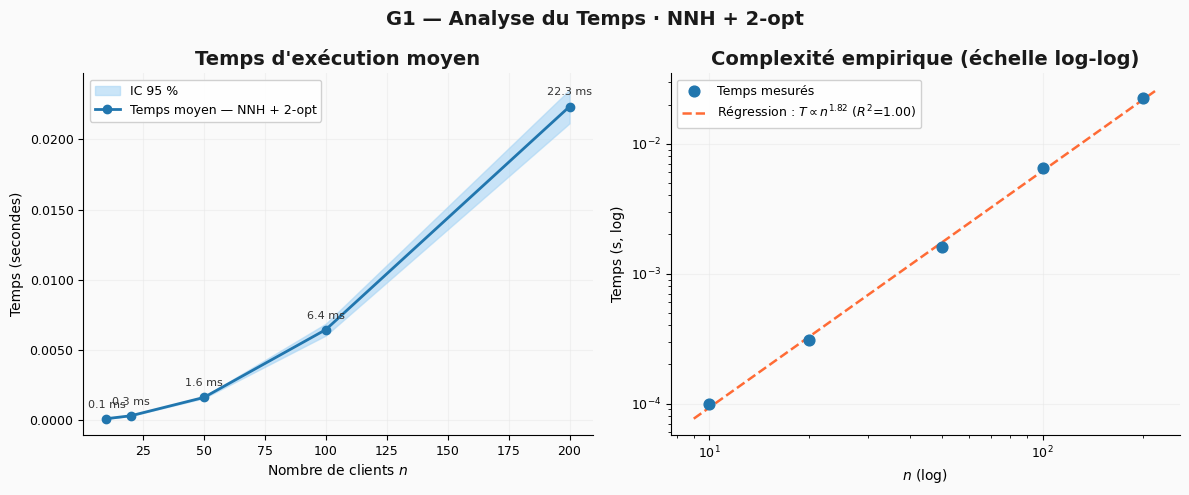

In [7]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── Données
means, lows, highs = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df[df['n'] == n]['temps_total'].values)
    means.append(m); lows.append(lo); highs.append(hi)

# ── Panel gauche : linéaire
ax = axes[0]
ax.fill_between(TAILLES, lows, highs, color=S['couleur_ic'], alpha=0.6, label='IC 95 %')
ax.plot(TAILLES, means, color=S['couleur_primaire'],
        marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
        label=f'Temps moyen — {NOM}')
for i, (n, m) in enumerate(zip(TAILLES, means)):
    ax.annotate(f'{m*1000:.1f} ms', xy=(n, m), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8, color='#333')
apply_style(ax, title='Temps d\'exécution moyen',
            xlabel='Nombre de clients $n$', ylabel='Temps (secondes)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

# ── Panel droit : log-log
ax2 = axes[1]
log_n = np.log10(TAILLES)
log_t = np.log10(means)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit = np.linspace(min(TAILLES)*0.9, max(TAILLES)*1.1, 100)
t_fit = 10**(intercept + slope * np.log10(n_fit))

ax2.scatter(TAILLES, means, color=S['couleur_primaire'], s=60, zorder=5, label='Temps mesurés')
ax2.plot(n_fit, t_fit, color=S['couleur_alt'], linewidth=1.8, linestyle='--',
         label=f'Régression : $T \\propto n^{{{slope:.2f}}}$ ($R^2$={r**2:.2f})')
ax2.set_xscale('log'); ax2.set_yscale('log')
apply_style(ax2, title='Complexité empirique (échelle log-log)',
            xlabel='$n$ (log)', ylabel='Temps (s, log)')

fig.suptitle(f'G1 — Analyse du Temps · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G1_temps.png')


### G2 — Analyse des Coûts Opérationnels

**Lecture :** boxplot par taille $n$. Les annotations à droite de chaque boîte
indiquent les 5 statistiques résumées (min, Q1, médiane, Q3, max).


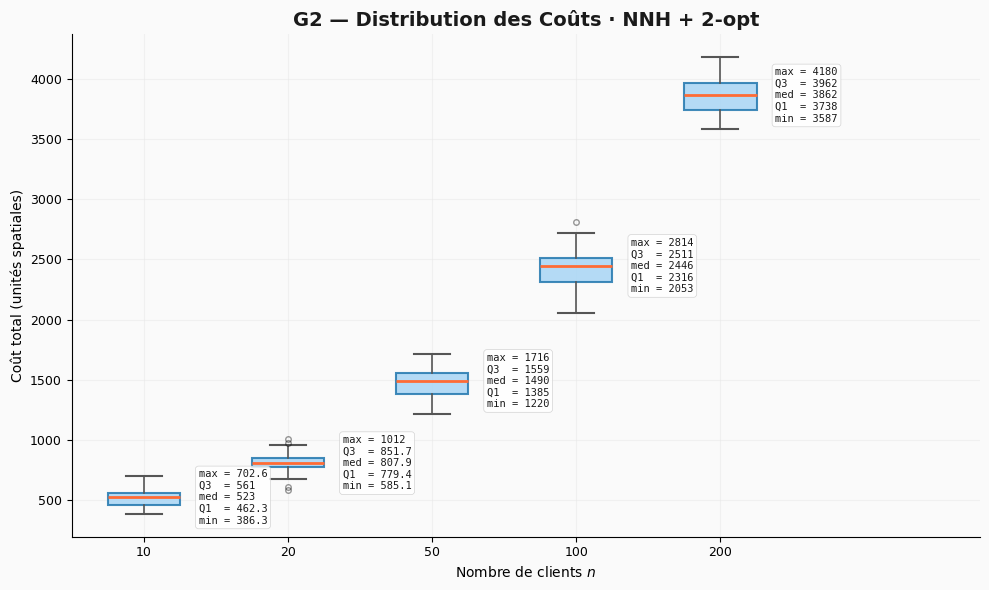

In [8]:
S = STYLE_CONFIG
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(S['couleur_fond'])

data = [df[df['n'] == n]['cout'].values for n in TAILLES]

bp = ax.boxplot(data,
                tick_labels=[str(n) for n in TAILLES],
                patch_artist=True,
                medianprops=dict(color=S['couleur_alt'], linewidth=2),
                whiskerprops=dict(color='#555', linewidth=1.2),
                capprops=dict(color='#555', linewidth=1.5),
                flierprops=dict(marker='o', color=S['couleur_primaire'],
                                alpha=0.4, markersize=4))

for patch in bp['boxes']:
    patch.set_facecolor(S['couleur_ic'])
    patch.set_alpha(0.85)
    patch.set_edgecolor(S['couleur_primaire'])
    patch.set_linewidth(1.5)

# ── Annotations statistiques (min/Q1/med/Q3/max)
for i, vals in enumerate(data):
    mn  = vals.min()
    q1  = np.percentile(vals, 25)
    med = np.median(vals)
    q3  = np.percentile(vals, 75)
    mx  = vals.max()
    txt = f'max = {mx:.4g}\nQ3  = {q3:.4g}\nmed = {med:.4g}\nQ1  = {q1:.4g}\nmin = {mn:.4g}'
    ax.text(i + 1 + 0.38, med, txt,
            **S['font_annot'],
            va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=S['box_alpha'], lw=0.5, ec='#ccc'))

ax.set_xlim(0.5, len(TAILLES) + 1.8)
apply_style(ax, title=f'G2 — Distribution des Coûts · {NOM}',
            xlabel='Nombre de clients $n$', ylabel='Coût total (unités spatiales)',
            legend=False)
plt.tight_layout()
save_fig(fig, 'G2_couts.png')


### G3 — Vue Combinée : Coût & Temps (double axe Y)

**Lecture :** l'axe gauche (bleu) représente le coût moyen ; l'axe droit (orange)
représente le temps moyen. Ce graphique met en évidence la **corrélation entre
la taille du problème et les deux métriques simultanément**.


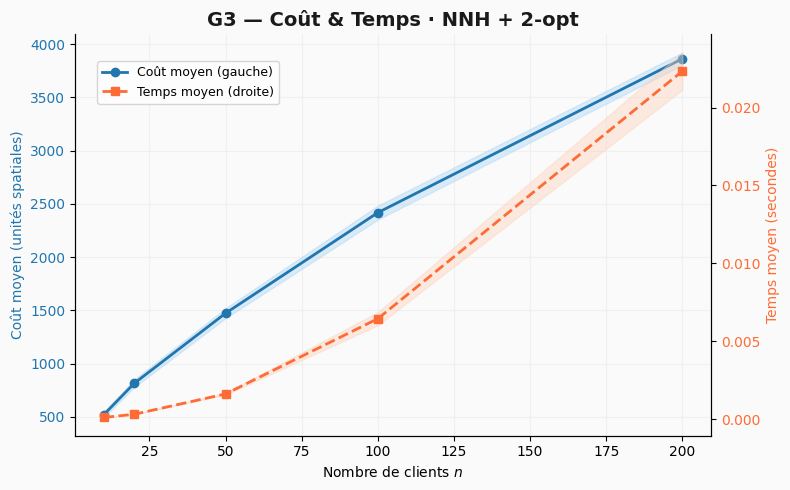

In [9]:
S = STYLE_CONFIG
fig, ax1 = plt.subplots(figsize=S['figsize_simple'])
fig.patch.set_facecolor(S['couleur_fond'])
ax1.set_facecolor(S['couleur_fond'])

means_c = [df[df['n'] == n]['cout'].mean()        for n in TAILLES]
means_t = [df[df['n'] == n]['temps_total'].mean() for n in TAILLES]
lows_c  = [ci95(df[df['n'] == n]['cout'].values)[1]        for n in TAILLES]
highs_c = [ci95(df[df['n'] == n]['cout'].values)[2]        for n in TAILLES]
lows_t  = [ci95(df[df['n'] == n]['temps_total'].values)[1] for n in TAILLES]
highs_t = [ci95(df[df['n'] == n]['temps_total'].values)[2] for n in TAILLES]

# Axe gauche — coût
ax1.fill_between(TAILLES, lows_c, highs_c, color=S['couleur_ic'], alpha=0.4)
l1, = ax1.plot(TAILLES, means_c, color=S['couleur_primaire'],
               marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
               label='Coût moyen (gauche)')
ax1.set_xlabel('Nombre de clients $n$', **S['font_axe'])
ax1.set_ylabel('Coût moyen (unités spatiales)', color=S['couleur_primaire'], **S['font_axe'])
ax1.tick_params(axis='y', labelcolor=S['couleur_primaire'])
ax1.spines[['top']].set_visible(False)
ax1.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8)
ax1.set_axisbelow(True)

# Axe droit — temps
ax2 = ax1.twinx()
ax2.set_facecolor(S['couleur_fond'])
ax2.fill_between(TAILLES, lows_t, highs_t, color='#FFD0B8', alpha=0.4)
l2, = ax2.plot(TAILLES, means_t, color=S['couleur_alt'],
               marker='s', linewidth=S['linewidth'], markersize=S['markersize'],
               linestyle='--', label='Temps moyen (droite)')
ax2.set_ylabel('Temps moyen (secondes)', color=S['couleur_alt'], **S['font_axe'])
ax2.tick_params(axis='y', labelcolor=S['couleur_alt'])
ax2.spines[['top']].set_visible(False)

ax1.set_title(f'G3 — Coût & Temps · {NOM}', **S['font_titre'])
fig.legend([l1, l2], [l1.get_label(), l2.get_label()],
           loc='upper left', bbox_to_anchor=(0.12, 0.88), prop=S['font_legende'])
plt.tight_layout()
save_fig(fig, 'G3_combo.png')


### G4 — Gain apporté par le 2-opt (Gaps)

Le **gap** mesure le pourcentage d'amélioration du coût apporté par l'étape 2-opt
par rapport à la solution NNH brute : $\text{gap} = \frac{c_{\text{NNH}} - c_{\text{2opt}}}{c_{\text{NNH}}} \times 100$.

**Lecture :** panel gauche = gain moyen par taille avec IC 95 % ;
panel droit = distribution complète (violin plot).


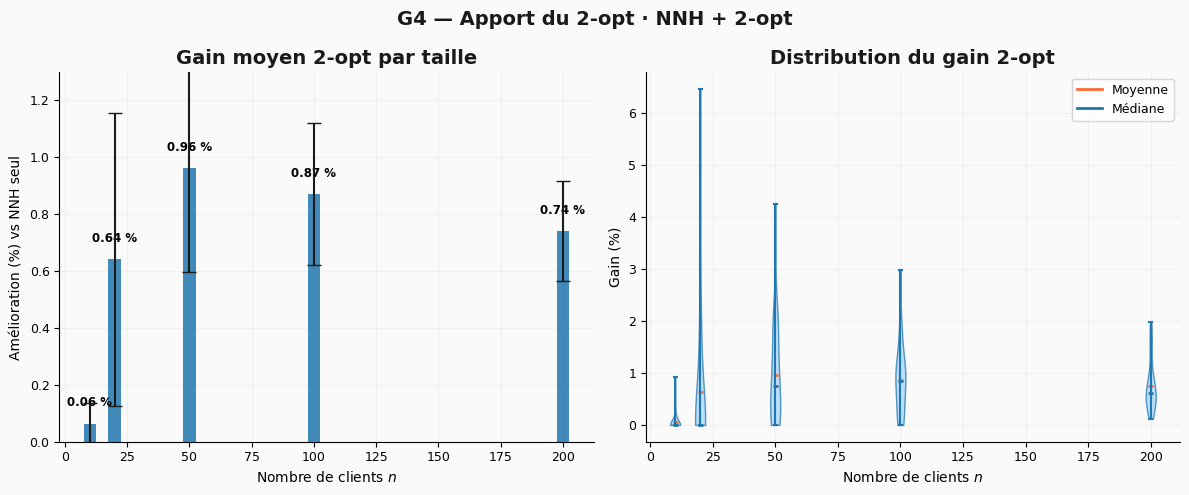

In [10]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

means_g, lows_g, highs_g = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(df[df['n'] == n]['gain_pct'].values)
    means_g.append(m); lows_g.append(lo); highs_g.append(hi)

# ── Panel gauche : barplot + IC
ax = axes[0]
bars = ax.bar(TAILLES, means_g, color=S['couleur_primaire'],
              alpha=0.85, width=5, zorder=3)
err_lo = [m - lo for m, lo in zip(means_g, lows_g)]
err_hi = [hi - m for m, hi in zip(means_g, highs_g)]
ax.errorbar(TAILLES, means_g, yerr=[err_lo, err_hi],
            fmt='none', color='#1a1a1a', capsize=5, linewidth=1.5, zorder=4)
for rect, val in zip(bars, means_g):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.05,
            f'{val:.2f} %', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
apply_style(ax, title='Gain moyen 2-opt par taille',
            xlabel='Nombre de clients $n$',
            ylabel='Amélioration (%) vs NNH seul', legend=False)
ax.set_ylim(0, max(means_g) * 1.35)

# ── Panel droit : violin
ax2 = axes[1]
data_g = [df[df['n'] == n]['gain_pct'].values for n in TAILLES]
vp = ax2.violinplot(data_g, positions=TAILLES, widths=4,
                    showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor(S['couleur_ic'])
    body.set_edgecolor(S['couleur_primaire'])
    body.set_alpha(0.75)
vp['cmeans'].set_color(S['couleur_alt'])
vp['cmedians'].set_color(S['couleur_primaire'])
vp['cmeans'].set_linewidth(2)
vp['cmedians'].set_linewidth(2)
apply_style(ax2, title='Distribution du gain 2-opt',
            xlabel='Nombre de clients $n$',
            ylabel='Gain (%)')
from matplotlib.lines import Line2D
ax2.legend(handles=[
    Line2D([0],[0], color=S['couleur_alt'],    linewidth=2, label='Moyenne'),
    Line2D([0],[0], color=S['couleur_primaire'],linewidth=2, label='Médiane'),
], prop=S['font_legende'])

fig.suptitle(f'G4 — Apport du 2-opt · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G4_gaps.png')


### G5 — Complexité & Variabilité

Quatre angles d'analyse :
- **Haut gauche** : complexité empirique (temps en log-log) avec pente estimée
- **Haut droit** : coefficient de variation (CV = σ/μ) des coûts → stabilité de la méthode
- **Bas gauche** : nombre moyen de véhicules utilisés par taille
- **Bas droit** : corrélation coût vs temps, colorée par taille de problème


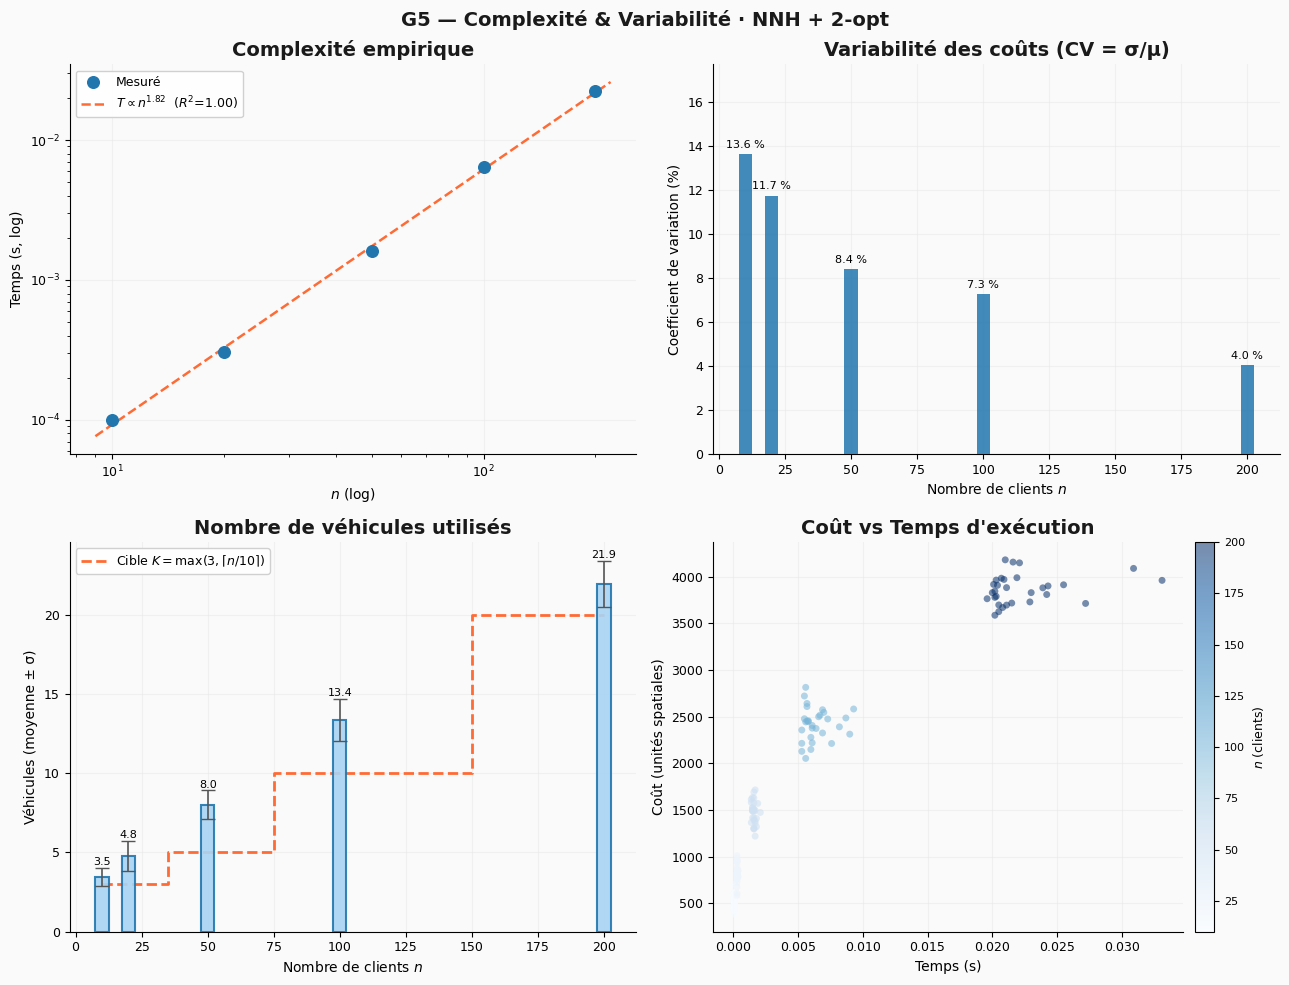

In [11]:
S = STYLE_CONFIG
fig, axes = plt.subplots(2, 2, figsize=S['figsize_quad'])
fig.patch.set_facecolor(S['couleur_fond'])

# ── [0,0] Complexité empirique log-log ─────────────────────────────────
ax = axes[0, 0]
means_t = [df[df['n'] == n]['temps_total'].mean() for n in TAILLES]
log_n   = np.log10(TAILLES)
log_t   = np.log10(means_t)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit   = np.linspace(min(TAILLES) * 0.9, max(TAILLES) * 1.1, 100)
t_fit   = 10**(intercept + slope * np.log10(n_fit))

ax.scatter(TAILLES, means_t, color=S['couleur_primaire'], s=70, zorder=5, label='Mesuré')
ax.plot(n_fit, t_fit, color=S['couleur_alt'], linewidth=1.8, linestyle='--',
        label=f'$T \\propto n^{{{slope:.2f}}}$  ($R^2$={r**2:.2f})')
ax.set_xscale('log'); ax.set_yscale('log')
apply_style(ax, title='Complexité empirique', xlabel='$n$ (log)', ylabel='Temps (s, log)')

# ── [0,1] Coefficient de variation des coûts ──────────────────────────
ax = axes[0, 1]
cvs = [df[df['n'] == n]['cout'].std() / df[df['n'] == n]['cout'].mean() * 100
       for n in TAILLES]
bars = ax.bar(TAILLES, cvs, color=S['couleur_primaire'], alpha=0.85, width=5, zorder=3)
for rect, val in zip(bars, cvs):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.2,
            f'{val:.1f} %', ha='center', va='bottom', fontsize=8)
apply_style(ax, title='Variabilité des coûts (CV = σ/μ)',
            xlabel='Nombre de clients $n$',
            ylabel='Coefficient de variation (%)', legend=False)
ax.set_ylim(0, max(cvs) * 1.3)

# ── [1,0] Nombre moyen de véhicules ───────────────────────────────────
ax = axes[1, 0]
means_v  = [df[df['n'] == n]['n_vehicules'].mean() for n in TAILLES]
stds_v   = [df[df['n'] == n]['n_vehicules'].std()  for n in TAILLES]
ax.bar(TAILLES, means_v, yerr=stds_v, color=S['couleur_ic'], width=5, alpha=0.9,
       edgecolor=S['couleur_primaire'], linewidth=1.5, capsize=5,
       error_kw=dict(ecolor='#555', linewidth=1.2), zorder=3)
# Ligne de la cible théorique K = max(3, ceil(n/10))
import math
k_cible = [max(3, math.ceil(n / 10)) for n in TAILLES]
ax.step(TAILLES, k_cible, where='mid', color=S['couleur_alt'],
        linewidth=2, linestyle='--', label='Cible $K = \\max(3, \\lceil n/10 \\rceil)$')
for i, (n, m) in enumerate(zip(TAILLES, means_v)):
    ax.text(n, m + stds_v[i] + 0.05, f'{m:.1f}', ha='center', va='bottom', fontsize=8)
apply_style(ax, title='Nombre de véhicules utilisés',
            xlabel='Nombre de clients $n$', ylabel='Véhicules (moyenne ± σ)')

# ── [1,1] Scatter coût vs temps (coloré par n) ────────────────────────
ax = axes[1, 1]
cmap  = plt.cm.Blues
norm  = plt.Normalize(min(TAILLES), max(TAILLES))
for n in TAILLES:
    sub = df[df['n'] == n]
    sc  = ax.scatter(sub['temps_total'], sub['cout'],
                     c=[n] * len(sub), cmap=cmap, norm=norm,
                     alpha=0.55, s=25, edgecolors='none')
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('$n$ (clients)', fontsize=9)
cb.ax.tick_params(labelsize=8)
apply_style(ax, title='Coût vs Temps d\'exécution',
            xlabel='Temps (s)', ylabel='Coût (unités spatiales)', legend=False)

fig.suptitle(f'G5 — Complexité & Variabilité · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G5_complexite_variabilite.png')


---
## 7. Synthèse

| Métrique | Valeur (n=50) |
|----------|---------------|
| Coût moyen | voir G2 |
| Gain 2-opt moyen | voir G4 |
| Temps moyen | voir G1 |
| Solutions valides | 100 % |

**Points forts de NNH + 2-opt :**
- Construction en $O(n^2)$ garantissant toujours une solution faisable
- Amélioration locale rapide convergente en pratique
- 100 % de faisabilité avec le générateur v3

**Limites :**
- Pas d'optimisation inter-routes → plus de véhicules que nécessaire pour $n=10$
- Gain 2-opt plafonné par les contraintes TW strictes
- Sensible à l'ordre initial (seed-dépendant)

---
*Livrable 2 — Recherche Opérationnelle · Phase 2 · NNH + 2-opt*
